In [9]:
#%pip uninstall serial
#%pip install pyserial

In [ ]:
# see 06_Analog_ADC_TempInterpV3.ino

In [1]:
import pandas as pd
import numpy as np 
import matplotlib .pyplot as plt
import serial

# read serial

In [1]:


# Open COM11 (change baudrate if needed)
ser = serial.Serial("COM11", 115200)
k= 0
arr=[]
while True:
    data = ser.readline().decode(errors="ignore").strip()
    if data:
        ##print(k, data)
        arr.append(data)
        k=k+1
        if k%10==0:
            print(k)
        if k>400:
            break
ser.close()
print("Port closed.")

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
Port closed.


In [2]:
ser.close()
print("Port closed.")

Port closed.


In [ ]:
# ThermMes_P = A2
# ThermMes_S = A6

In [5]:
arr[::2][:10]

['dt(us)=16 | 417 3543 109.06 1459 2521 2337 144 2928 27',
 'dt(us)=16 | 408 3544 109.09 1459 2523 2339 149 2930 24',
 'dt(us)=16 | 408 3541 109.00 1457 2523 2340 142 2931 24',
 'dt(us)=16 | 411 3542 109.03 1458 2520 2338 142 2930 26',
 'dt(us)=17 | 409 3544 109.09 1462 2523 2338 146 2931 27',
 'dt(us)=16 | 405 3541 109.00 1461 2523 2338 140 2932 26',
 'dt(us)=17 | 408 3541 109.00 1457 2520 2338 141 2932 27',
 'dt(us)=16 | 404 3543 109.06 1459 2521 2337 140 2931 27',
 'dt(us)=16 | 420 3543 109.06 1457 2520 2338 141 2929 23',
 'dt(us)=16 | 397 3543 109.06 1459 2521 2338 142 2930 26']

In [16]:
data = [x.split(" | ")[1] for x in arr[::2]]
data  = [x.split(" ") for x in data]
data[:5]

[['417', '3543', '109.06', '1459', '2521', '2337', '144', '2928', '27'],
 ['408', '3544', '109.09', '1459', '2523', '2339', '149', '2930', '24'],
 ['408', '3541', '109.00', '1457', '2523', '2340', '142', '2931', '24'],
 ['411', '3542', '109.03', '1458', '2520', '2338', '142', '2930', '26'],
 ['409', '3544', '109.09', '1462', '2523', '2338', '146', '2931', '27']]

In [25]:
cols= ['a0', 'a1', "vout", 'a2', 'a3', 'a4', 'a5', 'a6', 'a7']#, 'a8', 'a9']
df = pd.DataFrame(data, columns = cols).astype("float32")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7
0,417.0,3543.0,109.059998,1459.0,2521.0,2337.0,144.0,2928.0,27.0
1,408.0,3544.0,109.089996,1459.0,2523.0,2339.0,149.0,2930.0,24.0
2,408.0,3541.0,109.000000,1457.0,2523.0,2340.0,142.0,2931.0,24.0
3,411.0,3542.0,109.029999,1458.0,2520.0,2338.0,142.0,2930.0,26.0
4,409.0,3544.0,109.089996,1462.0,2523.0,2338.0,146.0,2931.0,27.0
...,...,...,...,...,...,...,...,...,...
196,406.0,3544.0,109.089996,1459.0,2522.0,2337.0,146.0,2930.0,25.0
197,416.0,3543.0,109.059998,1458.0,2521.0,2337.0,144.0,2930.0,25.0
198,409.0,3541.0,109.000000,1459.0,2522.0,2338.0,141.0,2931.0,26.0
199,426.0,3543.0,109.059998,1460.0,2521.0,2338.0,144.0,2932.0,26.0


In [27]:
df.to_csv("data/temp_est1.csv" , index = False)

# temp1

In [21]:
vcc = 3.328 # measurement 

In [22]:
CTN = pd.read_csv(r"data/CTN_Data.csv")
CTN.head()

,Point,temp,fac
0,1,125.000000,0.530219
1,2,112.037037,0.708538
2,3,100.071225,0.968181
3,4,85.612536,1.383312
4,5,74.145299,1.932852


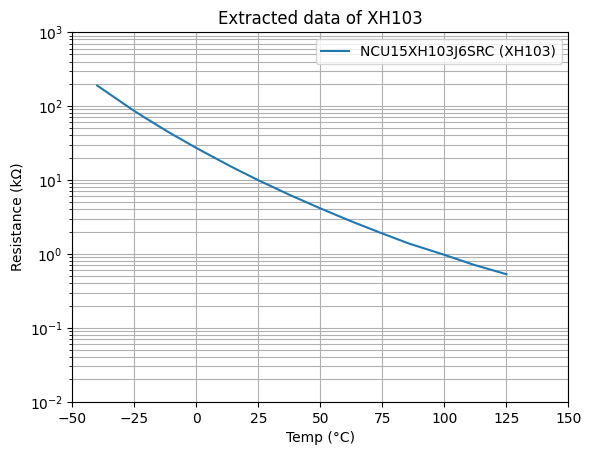

In [23]:
ax= plt.subplot()
CTN.plot(x="temp", y="fac", ax=ax, label="NCU15XH103J6SRC (XH103)")
ax.set_yscale("log")
ax.grid(which="both")
ax.set_xlim([-40,125])
ax.set_ylim([0.01,1000])
ax.set_title("Extracted data of XH103")
ax.set_xlabel("Temp (°C)")
ax.set_ylabel("Resistance (kΩ)")
ax.set_xticks(np.arange(-50, 160, 25))
plt.show()

In [24]:
len(CTN)

15

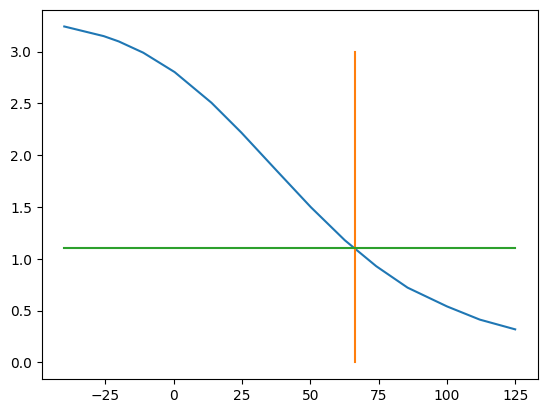

In [25]:

V_ref = 1.1 # V
R_2= 4.99 # kΩ
R_ntc = 10 # kΩ
V0=vcc # V
V_out= V0*R_ntc/(R_2+R_ntc) # V
V_out = vcc*CTN.fac/(CTN.fac+R_2)
Temp_V_ref = np.interp(x=[V_ref], fp=CTN.temp, xp=V_out)[0]


plt.plot(CTN.temp, V_out)
plt.plot([Temp_V_ref , Temp_V_ref ], [0,3])
plt.plot(CTN.temp,[V_ref]*len(CTN))

In [26]:
df = pd.read_csv(r"data/temp_est1.csv")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7
0,417.0,3543.0,109.06,1459.0,2521.0,2337.0,144.0,2928.0,27.0
1,408.0,3544.0,109.09,1459.0,2523.0,2339.0,149.0,2930.0,24.0
2,408.0,3541.0,109.00,1457.0,2523.0,2340.0,142.0,2931.0,24.0
3,411.0,3542.0,109.03,1458.0,2520.0,2338.0,142.0,2930.0,26.0
4,409.0,3544.0,109.09,1462.0,2523.0,2338.0,146.0,2931.0,27.0
...,...,...,...,...,...,...,...,...,...
196,406.0,3544.0,109.09,1459.0,2522.0,2337.0,146.0,2930.0,25.0
197,416.0,3543.0,109.06,1458.0,2521.0,2337.0,144.0,2930.0,25.0
198,409.0,3541.0,109.00,1459.0,2522.0,2338.0,141.0,2931.0,26.0
199,426.0,3543.0,109.06,1460.0,2521.0,2338.0,144.0,2932.0,26.0


In [27]:
ADCMAX = 2**12
ADCMAX

4096

In [28]:
# Vref 2.048v
Vref2048= vcc*df.a3/ADCMAX 
Vref2048

0      2.048312
1      2.049937
2      2.049937
3      2.047500
4      2.049937
         ...   
196    2.049125
197    2.048312
198    2.049125
199    2.048312
200    2.049125
Name: a3, Length: 201, dtype: float64

In [29]:
# ThermMes_P = A2
# ThermMes_S = A6

In [30]:
# TX08F103F3435ER
# https://www.mouser.fr/datasheet/2/281/NCU15XH103J6SRC-1519743.pdf

In [31]:
A2V= vcc*df.a2/ADCMAX 
A6V= vcc*df.a6/ADCMAX 
A2V[:5], A6V[:5]

(0    1.185437
 1    1.185437
 2    1.183812
 3    1.184625
 4    1.187875
 Name: a2, dtype: float64,
 0    2.379000
 1    2.380625
 2    2.381438
 3    2.380625
 4    2.381438
 Name: a6, dtype: float64)

In [32]:
CTN

,Point,temp,fac
0,1,125.000000,0.530219
1,2,112.037037,0.708538
2,3,100.071225,0.968181
3,4,85.612536,1.383312
4,5,74.145299,1.932852
5,6,62.678063,2.737084
6,7,50.213675,4.089049
7,8,37.749288,6.246571
8,9,24.786325,9.977725
9,10,13.817664,15.242314


In [33]:
# V_out = vcc*CTN.fac/(CTN.fac+R_2) ~### fac = rth 
# vcc/vout = 1+ R2/Rth==> R2/Rth = vcc/vout - 1
# Rth = R2/(vcc/vout-1)
# ThermMes_P = A2
RthP= R_2/(vcc/A2V-1)
RthS= R_2/(vcc/A6V-1)
RthP[:3], RthS[:3]

(0    2.760868
 1    2.760868
 2    2.754994
 Name: a2, dtype: float64,
 0    12.509178
 1    12.539194
 2    12.554240
 Name: a6, dtype: float64)

In [34]:
tempP = np.interp(x= RthP, xp=CTN.fac , fp= CTN.temp)#, left=None, right=None

In [35]:
tempS = np.interp(x= RthS, xp=CTN.fac , fp= CTN.temp)#, left=None, right=None

In [36]:
tempP[:2], tempS[:2]

(array([62.45878738, 62.45878738]), array([19.51209496, 19.44955779]))

In [39]:
ADCMAX, vcc, R_2
#(4096, 3.328, 4.99)

(4096, 3.328, 4.99)

In [40]:
A6V= vcc*df.a6/ADCMAX 
RthS= R_2/(vcc/A6V-1)
np.interp(x= RthS, xp=CTN.fac , fp= CTN.temp)[:5]

array([19.51209496, 19.44955779, 19.41820868, 19.44955779, 19.41820868])

In [49]:
R21= 4.99 # kΩ
Rth = np.interp(x= RthS, xp=CTN.fac , fp= CTN.temp).mean()
vout1= df.a2.mean()
vout2= df.a6.mean()
R22= (vout1/vout2) *(Rth+R21)-Rth
R22

np.float64(-7.275379367094024)

In [ ]:
# 5k

In [62]:
vout = A2V.mean()
print(vout)
print(Rth)
R22=10
V_out = vcc*Rth/(Rth+R22)
R22 = vcc*Rth/vout-Rth
print(R22)
print(vcc*Rth/(Rth +R22))


_="""
1.1849524253731343
19.424095188777716
35.12947793707704
1.1849524253731345
"""

1.1849524253731343
19.424095188777716
35.12947793707704
1.1849524253731345


# Verification

## read serial

In [5]:


# Open COM11 (change baudrate if needed)
ser = serial.Serial("COM4", 115200)
k= 0
arr=[]
while True:
    data = ser.readline().decode(errors="ignore").strip()
    #print(data)
    if data:
        ##print(k, data)
        arr.append(data)
        k=k+1
        if k%10==0:
            print(k)
        if k>400:
            break
ser.close()
print("Port closed.")

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
Port closed.


In [6]:
ser.close()
print("Port closed.")

Port closed.


In [ ]:
# ThermMes_P = A2
# ThermMes_S = A6

In [7]:
arr[::2][:10]

['dt(us)=16 | 404 3546 109.15 1454 2519 2334 147 2903 27 1.44 20.31',
 'dt(us)=17 | 394 3539 108.94 1451 2520 2335 143 2904 26 1.12 20.34',
 'dt(us)=17 | 407 3543 109.06 1451 2521 2335 144 2899 24 0.48 20.31',
 'dt(us)=17 | 429 3546 109.15 1455 2521 2335 141 2898 24 0.48 20.37',
 'dt(us)=17 | 429 3544 109.09 1455 2522 2335 144 2903 25 0.80 20.28',
 'dt(us)=17 | 402 3545 109.12 1455 2524 2336 147 2900 25 0.80 20.31',
 'dt(us)=17 | 412 3544 109.09 1453 2520 2335 138 2898 28 1.76 20.34',
 'dt(us)=17 | 426 3542 109.03 1453 2521 2334 151 2899 27 1.44 20.34',
 'dt(us)=17 | 413 3544 109.09 1452 2519 2334 139 2901 23 0.16 20.37',
 'dt(us)=17 | 416 3542 109.03 1452 2520 2334 146 2901 26 1.12 20.25']

In [11]:
data = [x.split(" | ")[1] for x in arr[::2]]
data  = [x.split(" ") for x in data]
print(data[:5])

[['404', '3546', '109.15', '1454', '2519', '2334', '147', '2903', '27', '1.44', '20.31'], ['394', '3539', '108.94', '1451', '2520', '2335', '143', '2904', '26', '1.12', '20.34'], ['407', '3543', '109.06', '1451', '2521', '2335', '144', '2899', '24', '0.48', '20.31'], ['429', '3546', '109.15', '1455', '2521', '2335', '141', '2898', '24', '0.48', '20.37'], ['429', '3544', '109.09', '1455', '2522', '2335', '144', '2903', '25', '0.80', '20.28']]


In [13]:
np.array(data).shape

(201, 11)

In [16]:
cols= ['a0', 'a1', "vout", 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', "Vin", "tempS"]#, 'a8', 'a9']
df = pd.DataFrame(data, columns = cols).astype("float32")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7,Vin,tempS
0,404.0,3546.0,109.150002,1454.0,2519.0,2334.0,147.0,2903.0,27.0,1.44,20.309999
1,394.0,3539.0,108.940002,1451.0,2520.0,2335.0,143.0,2904.0,26.0,1.12,20.340000
2,407.0,3543.0,109.059998,1451.0,2521.0,2335.0,144.0,2899.0,24.0,0.48,20.309999
3,429.0,3546.0,109.150002,1455.0,2521.0,2335.0,141.0,2898.0,24.0,0.48,20.370001
4,429.0,3544.0,109.089996,1455.0,2522.0,2335.0,144.0,2903.0,25.0,0.80,20.280001
...,...,...,...,...,...,...,...,...,...,...,...
196,419.0,3542.0,109.029999,1452.0,2519.0,2341.0,149.0,2900.0,25.0,0.80,20.309999
197,426.0,3546.0,109.150002,1451.0,2520.0,2340.0,144.0,2898.0,24.0,0.48,20.370001
198,406.0,3541.0,109.000000,1451.0,2522.0,2342.0,149.0,2899.0,25.0,0.80,20.400000
199,427.0,3540.0,108.970001,1450.0,2521.0,2341.0,144.0,2899.0,24.0,0.48,20.340000


In [15]:
df.to_csv("data/temp_est2.csv" , index = False)

<Axes: >

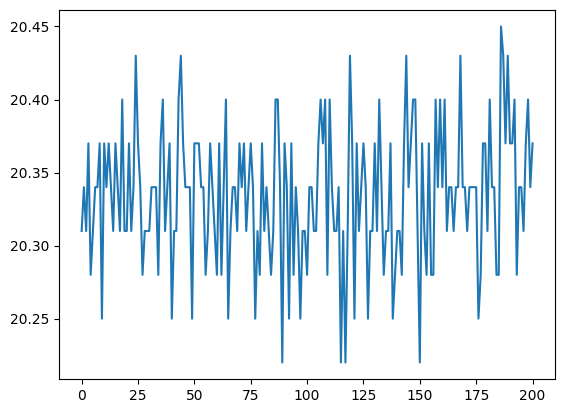

In [17]:
df.tempS.plot()

# secondary 

## READ SERIAL

In [63]:


# Open COM11 (change baudrate if needed)
ser = serial.Serial("COM4", 115200)
k= 0
arr=[]
while True:
    data = ser.readline().decode(errors="ignore").strip()
    #print(data)
    if data:
        ##print(k, data)
        arr.append(data)
        k=k+1
        if k%10==0:
            print(k)
        if k>400:
            break
ser.close()
print("Port closed.")

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
Port closed.


In [64]:
ser.close()
print("Port closed.")

Port closed.


In [ ]:
# ThermMes_P = A2
# ThermMes_S = A6

In [65]:
arr[::2][:10]

['dt(us)=17 | 405 3543 109.06 1447 2521 2348 145 2897 27 1.44 20.51 9.22',
 'dt(us)=17 | 415 3539 108.94 1445 2521 2348 143 2892 24 0.48 20.54 9.17',
 'dt(us)=17 | 417 3543 109.06 1448 2522 2348 143 2892 24 0.48 20.57 9.07',
 'dt(us)=17 | 429 3542 109.03 1444 2520 2348 148 2892 26 1.12 20.54 9.15',
 'dt(us)=17 | 406 3543 109.06 1448 2523 2347 145 2892 23 0.16 20.45 9.10',
 'dt(us)=17 | 417 3540 108.97 1445 2522 2347 138 2891 25 0.80 20.48 9.10',
 'dt(us)=17 | 414 3541 109.00 1444 2523 2347 142 2893 27 1.44 20.54 9.07',
 'dt(us)=17 | 414 3544 109.09 1445 2517 2347 154 2893 24 0.48 20.60 9.10',
 'dt(us)=17 | 411 3543 109.06 1447 2521 2348 141 2894 25 0.80 20.54 9.20',
 'dt(us)=17 | 423 3542 109.03 1445 2520 2345 144 2896 29 2.09 20.54 9.17']

In [66]:
data = [x.split(" | ")[1] for x in arr[::2]]
data  = [x.split(" ") for x in data]
print(data[:5])

[['405', '3543', '109.06', '1447', '2521', '2348', '145', '2897', '27', '1.44', '20.51', '9.22'], ['415', '3539', '108.94', '1445', '2521', '2348', '143', '2892', '24', '0.48', '20.54', '9.17'], ['417', '3543', '109.06', '1448', '2522', '2348', '143', '2892', '24', '0.48', '20.57', '9.07'], ['429', '3542', '109.03', '1444', '2520', '2348', '148', '2892', '26', '1.12', '20.54', '9.15'], ['406', '3543', '109.06', '1448', '2523', '2347', '145', '2892', '23', '0.16', '20.45', '9.10']]


In [67]:
np.array(data).shape

(201, 12)

In [69]:
cols= ['a0', 'a1', "vout", 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', "Vin", "tempS","TempP"]#, 'a8', 'a9']
df = pd.DataFrame(data, columns = cols).astype("float32")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7,Vin,tempS,TempP
0,405.0,3543.0,109.059998,1447.0,2521.0,2348.0,145.0,2897.0,27.0,1.44,20.510000,9.22
1,415.0,3539.0,108.940002,1445.0,2521.0,2348.0,143.0,2892.0,24.0,0.48,20.540001,9.17
2,417.0,3543.0,109.059998,1448.0,2522.0,2348.0,143.0,2892.0,24.0,0.48,20.570000,9.07
3,429.0,3542.0,109.029999,1444.0,2520.0,2348.0,148.0,2892.0,26.0,1.12,20.540001,9.15
4,406.0,3543.0,109.059998,1448.0,2523.0,2347.0,145.0,2892.0,23.0,0.16,20.450001,9.10
...,...,...,...,...,...,...,...,...,...,...,...,...
196,403.0,3541.0,109.000000,1443.0,2520.0,2346.0,140.0,2892.0,24.0,0.48,20.480000,9.15
197,414.0,3545.0,109.120003,1449.0,2522.0,2347.0,148.0,2894.0,24.0,0.48,20.480000,9.20
198,411.0,3539.0,108.940002,1443.0,2519.0,2348.0,151.0,2895.0,27.0,1.44,20.540001,9.20
199,416.0,3540.0,108.970001,1444.0,2522.0,2349.0,151.0,2890.0,23.0,0.16,20.570000,9.20


In [70]:
df.to_csv("data/temp_est3.csv" , index = False)

<Axes: >

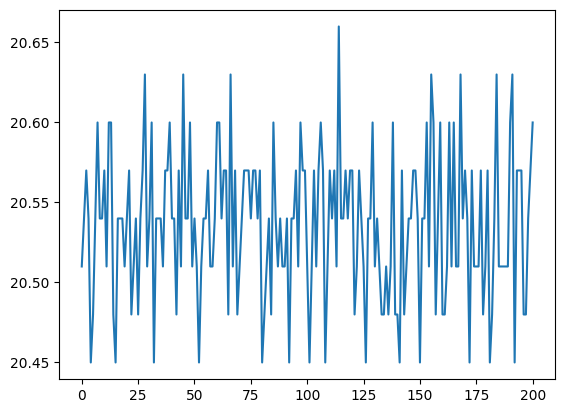

In [71]:
df.tempS.plot()

In [73]:
A2V= vcc*df.a2/ADCMAX 
A6V= vcc*df.a6/ADCMAX 
A2V[:5], A6V[:5]

(0    1.175688
 1    1.174062
 2    1.176500
 3    1.173250
 4    1.176500
 Name: a2, dtype: float32,
 0    2.353812
 1    2.349750
 2    2.349750
 3    2.349750
 4    2.349750
 Name: a6, dtype: float32)

In [75]:
vout = A2V.mean()
print(vout)
print(Rth)
#R22=10
V_out = vcc*Rth/(Rth+R22)
R22 = vcc*Rth/vout-Rth
print(R22)
print(vcc*Rth/(Rth +R22))


_="""
1.1849524253731343
19.424095188777716
35.12947793707704
1.1849524253731345
"""

1.1748469
19.424095188777716
35.59872478135449
1.174846887588501


## READ AFTER MODIFICATION

In [76]:
#float R_2 = 35.5987 ; //35.1294; 

# DERATING CHECK 

In [87]:


# Open COM11 (change baudrate if needed)
ser = serial.Serial("COM4", 115200)
k= 0
arr=[]
while True:
    data = ser.readline().decode(errors="ignore").strip()
    #print(data)
    print(data, end="\r") 
    if data:
        ##print(k, data)
        arr.append(data)


ser.close()
print("Port closed.")

dt(us)=17 | 412 3541 109.00 1444 2519 2342 139 2304 24 0.48 37.07 8.77 1200.000

KeyboardInterrupt: 

In [88]:
len(arr)

157

In [86]:
ser.close()

In [91]:
arr[5]

'dt(us)=17 | 411 3540 108.97 1445 2520 2353 145 2897 27 1.44 20.43 8.79 1200.00'

In [92]:
data = [x.split(" | ")[1] for x in arr[1::2]]
data  = [x.split(" ") for x in data]
print(data[:5])

[['408', '3542', '109.03', '1449', '2520', '2348', '156', '2896', '28', '1.76', '20.51', '8.79', '1200.00'], ['415', '3546', '109.15', '1449', '2519', '2339', '140', '2894', '29', '2.09', '20.45', '8.87', '1200.00'], ['411', '3540', '108.97', '1445', '2520', '2353', '145', '2897', '27', '1.44', '20.43', '8.79', '1200.00'], ['409', '3545', '109.12', '1449', '2522', '2340', '146', '2895', '28', '1.76', '20.51', '8.75', '1200.00'], ['410', '3543', '109.06', '1448', '2521', '2340', '150', '2895', '26', '1.12', '20.45', '8.79', '1200.00']]


In [94]:
np.array(data).shape

(78, 13)

In [95]:
cols= ['a0', 'a1', "vout", 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', "Vin", "tempS","TempP","ene"]#, 'a8', 'a9']
df = pd.DataFrame(data, columns = cols).astype("float32")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7,Vin,tempS,TempP,ene
0,408.0,3542.0,109.029999,1449.0,2520.0,2348.0,156.0,2896.0,28.0,1.76,20.510000,8.79,1200.0
1,415.0,3546.0,109.150002,1449.0,2519.0,2339.0,140.0,2894.0,29.0,2.09,20.450001,8.87,1200.0
2,411.0,3540.0,108.970001,1445.0,2520.0,2353.0,145.0,2897.0,27.0,1.44,20.430000,8.79,1200.0
3,409.0,3545.0,109.120003,1449.0,2522.0,2340.0,146.0,2895.0,28.0,1.76,20.510000,8.75,1200.0
4,410.0,3543.0,109.059998,1448.0,2521.0,2340.0,150.0,2895.0,26.0,1.12,20.450001,8.79,1200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,416.0,3543.0,109.059998,1448.0,2521.0,2344.0,143.0,2267.0,21.0,-0.48,38.070000,8.87,1200.0
74,393.0,3545.0,109.120003,1447.0,2521.0,2345.0,138.0,2277.0,24.0,0.48,37.709999,8.82,1200.0
75,425.0,3542.0,109.029999,1445.0,2521.0,2345.0,143.0,2286.0,22.0,-0.16,37.580002,8.72,1200.0
76,423.0,3541.0,109.000000,1443.0,2520.0,2346.0,146.0,2294.0,22.0,-0.16,37.430000,8.84,1200.0


<Axes: >

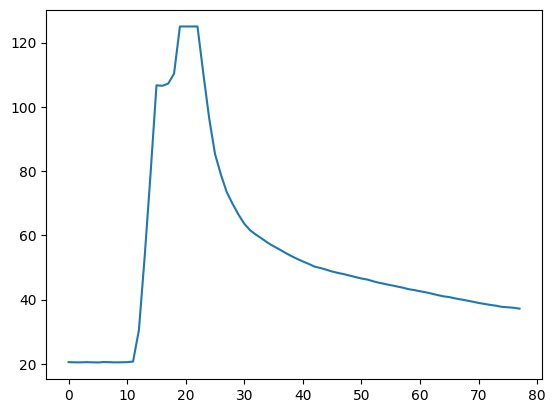

In [97]:
df.tempS.plot()

<Axes: >

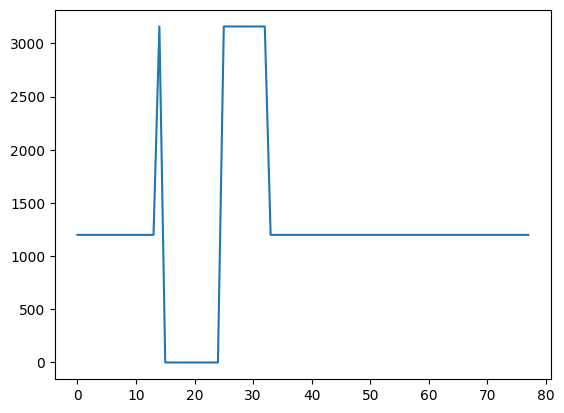

In [98]:
df.ene.plot()

In [96]:
df.to_csv("data/temp_est4.csv" , index = False)

# DERATING CHECK 2

In [100]:


# Open COM11 (change baudrate if needed)
ser = serial.Serial("COM4", 115200)
k= 0
arr=[]
while True:
    data = ser.readline().decode(errors="ignore").strip()
    #print(data)
    print(data, end="\r") 
    if data:
        ##print(k, data)
        arr.append(data)


ser.close()
print("Port closed.")

dt(us)=17 | 409 3542 109.03 1447 2519 2339 143 2122 24 0.48 42.85 8.84 1200.000

KeyboardInterrupt: 

In [101]:
len(arr)

236

In [102]:
ser.close()

In [103]:
arr[5]

'dt(us)=17 | 428 3541 109.00 1447 2520 2328 150 2910 24 0.48 20.07 8.75 1200.00'

In [104]:
data = [x.split(" | ")[1] for x in arr[1::2]]
data  = [x.split(" ") for x in data]
print(data[:5])

[['425', '3543', '109.06', '1450', '2521', '2331', '145', '2911', '26', '1.12', '19.97', '8.72', '1200.00'], ['420', '3542', '109.03', '1450', '2519', '2331', '145', '2910', '24', '0.48', '19.97', '8.77', '1200.00'], ['428', '3541', '109.00', '1447', '2520', '2328', '150', '2910', '24', '0.48', '20.07', '8.75', '1200.00'], ['418', '3541', '109.00', '1450', '2520', '2331', '145', '2910', '23', '0.16', '19.97', '8.75', '1200.00'], ['431', '3542', '109.03', '1449', '2522', '2332', '154', '2913', '29', '2.09', '20.04', '8.72', '1200.00']]


In [105]:
np.array(data).shape

(118, 13)

In [106]:
cols= ['a0', 'a1', "vout", 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', "Vin", "tempS","TempP","ene"]#, 'a8', 'a9']
df = pd.DataFrame(data, columns = cols).astype("float32")
df

,a0,a1,vout,a2,a3,a4,a5,a6,a7,Vin,tempS,TempP,ene
0,425.0,3543.0,109.059998,1450.0,2521.0,2331.0,145.0,2911.0,26.0,1.12,19.969999,8.72,1200.0
1,420.0,3542.0,109.029999,1450.0,2519.0,2331.0,145.0,2910.0,24.0,0.48,19.969999,8.77,1200.0
2,428.0,3541.0,109.000000,1447.0,2520.0,2328.0,150.0,2910.0,24.0,0.48,20.070000,8.75,1200.0
3,418.0,3541.0,109.000000,1450.0,2520.0,2331.0,145.0,2910.0,23.0,0.16,19.969999,8.75,1200.0
4,431.0,3542.0,109.029999,1449.0,2522.0,2332.0,154.0,2913.0,29.0,2.09,20.040001,8.72,1200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,403.0,3545.0,109.120003,1450.0,2520.0,2338.0,139.0,2085.0,24.0,0.48,44.040001,8.70,1200.0
114,410.0,3541.0,109.000000,1449.0,2520.0,2340.0,149.0,2091.0,20.0,-0.80,43.740002,8.82,1200.0
115,408.0,3542.0,109.029999,1452.0,2522.0,2339.0,139.0,2103.0,23.0,0.16,43.480000,8.72,1200.0
116,410.0,3545.0,109.120003,1450.0,2519.0,2339.0,148.0,2114.0,24.0,0.48,43.090000,8.75,1200.0


<Axes: >

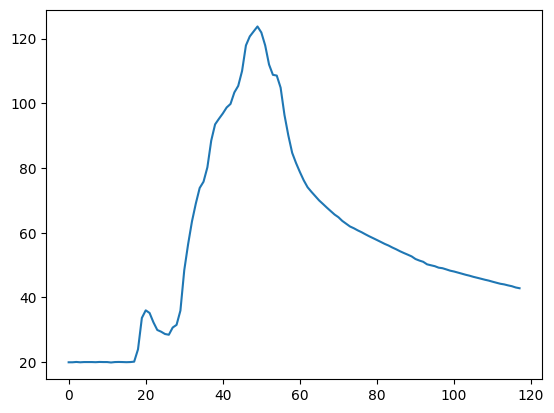

In [107]:
df.tempS.plot()

<Axes: >

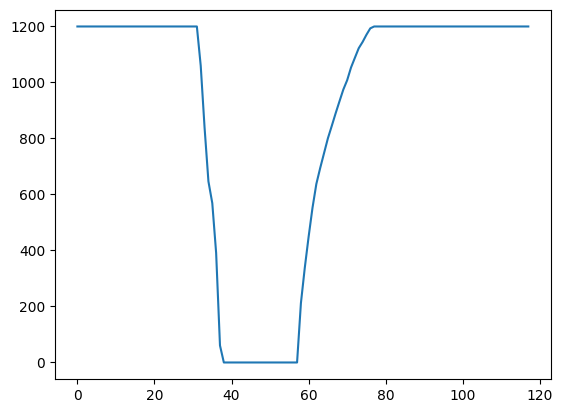

In [108]:
df.ene.plot()

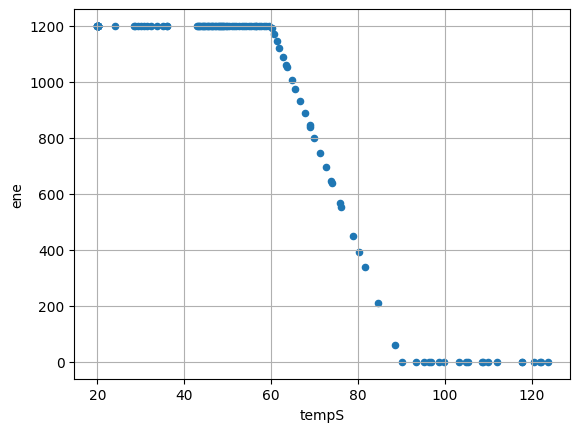

In [113]:
df.plot(x = "tempS", y = "ene", kind = "scatter")
plt.grid()

In [111]:
df.to_csv("data/temp_est5.csv" , index = False)

In [115]:
df= pd.read_csv("data/temp_est5.csv" )

<Axes: >

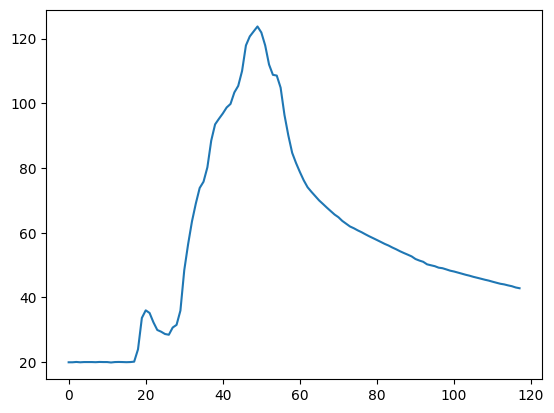

In [107]:
df.tempS.plot()

<Axes: >

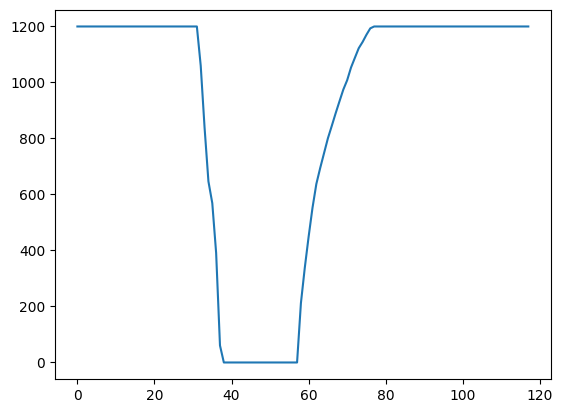

In [108]:
df.ene.plot()

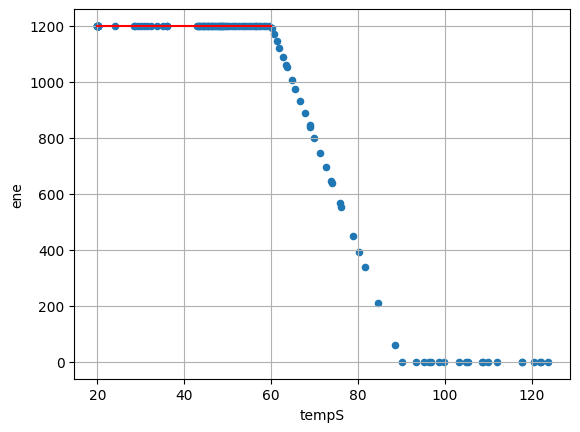

In [120]:
df.plot(x = "tempS", y = "ene", kind = "scatter")
plt.plot([20,60],[1200,1200], c="r")
plt.grid()